In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, AdaBoostRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.base import clone

In [ ]:

df = pd.read_csv("../../Datos/Originales/01_Optimizacion/Opt_dataset_4Objectives_CC.csv")
df.head()

,x1,x2,x3,x4,x5,x6,y1,y2,y3,y4
0,3.2,0.95,1.2,2.4,46.5,5.1,7.543477,0.000590,-0.809682,0.002764
1,1.2,0.95,1.0,0.1,45.0,4.8,5.377060,0.206311,-0.918555,0.225746
2,1.2,0.75,1.3,0.4,48.0,4.8,5.048992,0.033728,-0.908788,0.060608
3,1.4,0.85,0.8,0.1,49.0,4.7,5.681045,0.238174,-0.917285,0.244254
4,1.2,0.90,2.0,0.1,45.0,4.8,5.177121,0.016478,-0.914834,0.054130


In [3]:
X = df[["x1", "x2", "x3", "x4", "x5", "x6"]]
Y = df[["y1", "y2", "y3", "y4"]]

X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
)

comparamos distintos algoritmos con un 80 de train

In [5]:
modelos_nativos = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(),
    "Lasso":             Lasso(),
    "Decision Tree":     DecisionTreeRegressor(random_state=42),
    "Random Forest":     RandomForestRegressor(random_state=42),
    "Extra Trees":       ExtraTreesRegressor(random_state=42),
    "K-Neighbors":       KNeighborsRegressor(),
}

modelos_wrapped = {
    "Gradient Boosting":    GradientBoostingRegressor(random_state=42),
    "AdaBoost":             AdaBoostRegressor(random_state=42),
    "SVR":                  SVR(),
    "Neural Network (MLP)": MLPRegressor(max_iter=1000, random_state=42),
}

resultados = {}

for nombre, modelo in modelos_nativos.items():
    modelo.fit(X_train_full, Y_train_full)
    Y_pred = modelo.predict(X_test)
    r2 = r2_score(Y_test, Y_pred, multioutput="uniform_average")
    resultados[nombre] = r2
    print(f"{nombre.ljust(25)}: R2 (avg) = {r2:.4f}")

for nombre, modelo_base in modelos_wrapped.items():
    modelo = MultiOutputRegressor(modelo_base)
    modelo.fit(X_train_full, Y_train_full)
    Y_pred = modelo.predict(X_test)
    r2 = r2_score(Y_test, Y_pred, multioutput="uniform_average")
    resultados[nombre] = r2
    print(f"{nombre.ljust(25)}: R2 (avg) = {r2:.4f}")

ganador = max(resultados, key=resultados.get)
print(f"\nGANADOR: {ganador} (R2 base: {resultados[ganador]:.4f})\n")


Linear Regression        : R2 (avg) = 0.7511
Ridge                    : R2 (avg) = 0.7511
Lasso                    : R2 (avg) = 0.0847
Decision Tree            : R2 (avg) = 0.8238
Random Forest            : R2 (avg) = 0.9000
Extra Trees              : R2 (avg) = 0.9059
K-Neighbors              : R2 (avg) = 0.8182
Gradient Boosting        : R2 (avg) = 0.9213
AdaBoost                 : R2 (avg) = 0.8028
SVR                      : R2 (avg) = 0.0198
Neural Network (MLP)     : R2 (avg) = 0.6362

GANADOR: Gradient Boosting (R2 base: 0.9213)



GANADOR: Gradient Boosting (R2 base: 0.9213)


In [7]:
modelo_base = GradientBoostingRegressor(random_state=42)
modelo_multi = MultiOutputRegressor(modelo_base)

# Definimos la malla de hiperparámetros (nota el prefijo 'estimator__')
param_grid = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "estimator__max_depth": [3, 5, 7],
    "estimator__subsample": [0.7, 0.8, 1.0],
    "estimator__min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=modelo_multi,
    param_distributions=param_grid,
    n_iter=50,       # Número de combinaciones a probar
    scoring="r2",
    cv=5,            # Validación cruzada de 5 pliegues
    random_state=42,
    n_jobs=-1,       # Usar todos los núcleos del procesador
    verbose=1
)

search.fit(X_train_full, Y_train_full)

print("\nMejores hiperparámetros encontrados:")
for param, valor in search.best_params_.items():
    print(f"  {param}: {valor}")

# Extraemos el mejor modelo ya entrenado
modelo_ganador_tuneado = search.best_estimator_

# Predecimos sobre el conjunto de test aislado
Y_pred_tuned = modelo_ganador_tuneado.predict(X_test)
r2_tuned = r2_score(Y_test, Y_pred_tuned, multioutput="uniform_average")

print(f"\nR2 en Test (Promedio): {r2_tuned:.4f}\n")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejores hiperparámetros encontrados:
  estimator__subsample: 0.7
  estimator__n_estimators: 200
  estimator__min_samples_split: 2
  estimator__max_depth: 7
  estimator__learning_rate: 0.1

R2 en Test (Promedio): 0.9715




=== EVALUANDO TAMAÑOS DE TRAIN VS R2 ===
Train: 95% | Test: 05%  --->  R2: 0.9818
Train: 90% | Test: 09%  --->  R2: 0.9715
Train: 85% | Test: 15%  --->  R2: 0.9705
Train: 80% | Test: 19%  --->  R2: 0.9715
Train: 75% | Test: 25%  --->  R2: 0.9758
Train: 70% | Test: 30%  --->  R2: 0.9761
Train: 65% | Test: 35%  --->  R2: 0.9714
Train: 60% | Test: 40%  --->  R2: 0.9668
Train: 55% | Test: 44%  --->  R2: 0.9690
Train: 50% | Test: 50%  --->  R2: 0.9685
Train: 45% | Test: 55%  --->  R2: 0.9624
Train: 40% | Test: 60%  --->  R2: 0.9581
Train: 35% | Test: 65%  --->  R2: 0.9519
Train: 30% | Test: 70%  --->  R2: 0.9393
Train: 25% | Test: 75%  --->  R2: 0.9311
Train: 20% | Test: 80%  --->  R2: 0.9200
Train: 15% | Test: 85%  --->  R2: 0.9004
Train: 10% | Test: 90%  --->  R2: 0.8814
Train: 05% | Test: 95%  --->  R2: 0.8210


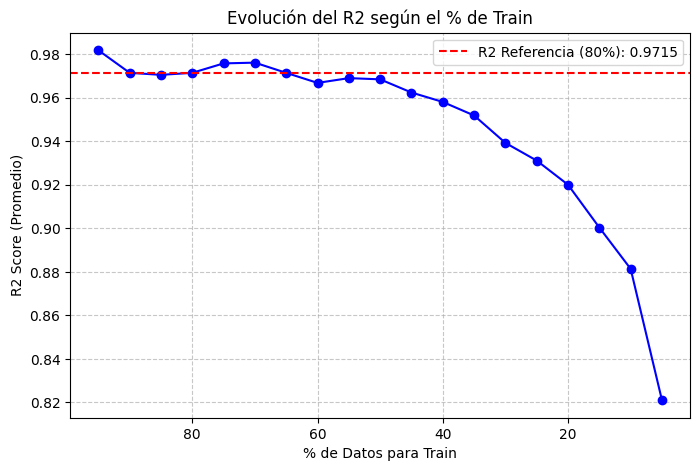

In [ ]:
import matplotlib.pyplot as plt
from sklearn.base import clone

print("\n=== EVALUANDO TAMAÑOS DE TRAIN VS R2 ===")

tamanos_train = [0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05]
historico_r2 = []

for size in tamanos_train:
    X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, train_size=size, random_state=42)
    
    modelo_eval = clone(modelo_ganador_tuneado)
    
    modelo_eval.fit(X_tr, Y_tr)
    Y_pr = modelo_eval.predict(X_te)
    
    r2_actual = r2_score(Y_te, Y_pr, multioutput="uniform_average")
    historico_r2.append(r2_actual)
    
    print(f"Train: {int(size*100):02d}% | Test: {int((1-size)*100):02d}%  --->  R2: {r2_actual:.4f}")

plt.figure(figsize=(8, 5))
plt.plot([int(s*100) for s in tamanos_train], historico_r2, marker='o', linestyle='-', color='b')
plt.title('Evolución del R2 según el % de Train')
plt.xlabel('% de Datos para Train')
plt.ylabel('R2 Score (Promedio)')
plt.gca().invert_xaxis() # Invertimos para ver cómo cae al reducir el train
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=r2_tuned, color='r', linestyle='--', label=f'R2 Referencia (80%): {r2_tuned:.4f}')
plt.legend()
plt.show()

Finalmente nos quedamos con 35% de train

In [11]:
import joblib
import os

ruta_carpeta = "../../Modelos"
os.makedirs(ruta_carpeta, exist_ok=True)

X_train_35, X_test_35, Y_train_35, Y_test_35 = train_test_split(
    X, Y, train_size=0.35, random_state=42
)

modelo_final = clone(search.best_estimator_)
modelo_final.fit(X_train_35, Y_train_35)

ruta_archivo = os.path.join(ruta_carpeta, "modelo_final_35_train.pkl")
joblib.dump(modelo_final, ruta_archivo)

print(f"Modelo guardado exitosamente en: {ruta_archivo}")

Modelo guardado exitosamente en: ../../Modelos\modelo_final_35_train.pkl
